<a href="https://colab.research.google.com/github/swayambel/numerical_integrator_analysis/blob/main/numerical_integrator_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numerical Integrator Stability Analysis

## 1. Introduction

Numerical integration methods are fundamental tools for solving dynamical systems that cannot be solved analytically. In celestial mechanics and orbital dynamics, the equations governing motion are often expressed as differential equations, which require numerical techniques to compute trajectories over time.

One of the simplest physical systems used to study numerical methods is the **two-body gravitational problem**, where a small body moves under the gravitational influence of a central mass. In an ideal analytical solution, certain physical quantities such as **total mechanical energy** and **angular momentum** remain conserved.

However, numerical integration methods introduce **truncation errors** at each timestep. Over long simulations these errors accumulate and can significantly alter the system’s behavior. As a result, different integrators exhibit different levels of stability and conservation accuracy.

The objective of this study is to investigate how various numerical integrators affect the long-term stability of orbital simulations.

Specifically, this project compares the following integration methods:

- Euler Method  
- Second-order Runge–Kutta (RK2)  
- Fourth-order Runge–Kutta (RK4)

The analysis focuses on three key diagnostics:

1. **Orbit geometry** – how the trajectory evolves over time  
2. **Energy conservation** – deviation of specific mechanical energy from its initial value  
3. **Radius drift** – long-term change in orbital radius  

By comparing these properties, we can understand how the order and structure of numerical integrators influence the accuracy and stability of gravitational simulations.

## 2. Two-Body Gravitational Model


In [1]:
import numpy as np
import matplotlib.pyplot as plt

GM = 1.0

def derivatives(state):
    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return np.array([vx, vy, ax, ay])


## 3. Euler Integrator

In [2]:
def euler_step(state, dt):
    return state + dt * derivatives(state)

In [3]:
dt = 0.05
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory = []

for _ in range(steps):
    trajectory.append(state[:2])
    state = euler_step(state, dt)

trajectory = np.array(trajectory)

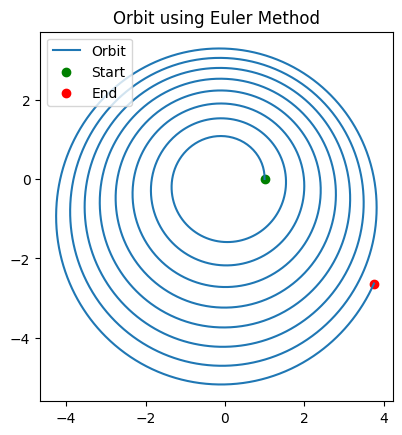

In [4]:
plt.plot(trajectory[:,0], trajectory[:,1], label="Orbit")
plt.scatter(trajectory[0,0], trajectory[0,1], color='green', label="Start")
plt.scatter(trajectory[-1,0], trajectory[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using Euler Method")
plt.show()

## 4. RK2 Integrator



In [5]:
def rk2_step(state, dt):
    k1 = derivatives(state)
    k2 = derivatives(state + dt * k1)

    return state + 0.5 * dt * (k1 + k2)

In [6]:
dt = 0.05
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_rk2 = []

for _ in range(steps):
    trajectory_rk2.append(state[:2])
    state = rk2_step(state, dt)

trajectory_rk2 = np.array(trajectory_rk2)

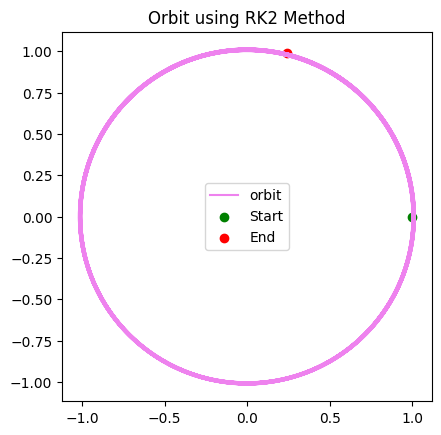

In [7]:
plt.plot(trajectory_rk2[:,0], trajectory_rk2[:,1], label ='orbit', color='violet')
plt.scatter(trajectory_rk2[0,0], trajectory_rk2[0,1], color='green', label="Start")
plt.scatter(trajectory_rk2[-1,0], trajectory_rk2[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using RK2 Method")
plt.show()

## 5. RK4 Integrator


In [8]:
def rk4_step(state, dt):
    k1 = derivatives(state)
    k2 = derivatives(state + 0.5 * dt * k1)
    k3 = derivatives(state + 0.5 * dt * k2)
    k4 = derivatives(state + dt * k3)

    return state + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [9]:
dt = 0.05
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_rk4 = []

for _ in range(steps):
    trajectory_rk4.append(state[:2])
    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)

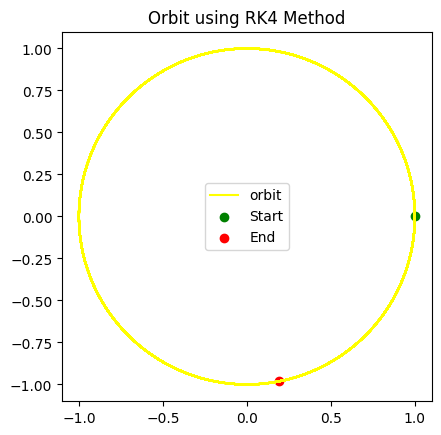

In [10]:
plt.plot(trajectory_rk4[:,0], trajectory_rk4[:,1], label='orbit', color='yellow')
plt.scatter(trajectory_rk4[0,0], trajectory_rk4[0,1], color='green', label="Start")
plt.scatter(trajectory_rk4[-1,0], trajectory_rk4[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using RK4 Method")
plt.show()

## 6. Orbit Comparison

In this section we compare the trajectories produced by the Euler, RK2, and RK4 integrators using the same timestep and initial conditions. This allows us to observe how numerical error affects orbital stability.

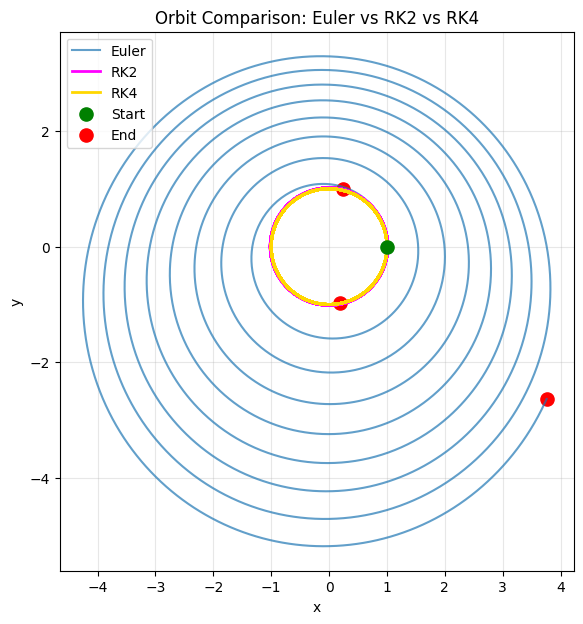

In [11]:
plt.figure(figsize=(7,7))

plt.plot(
    trajectory[:,0], trajectory[:,1],
    color="tab:blue",
    linewidth=1.5,
    alpha=0.7,
    label="Euler"
)

plt.plot(
    trajectory_rk2[:,0], trajectory_rk2[:,1],
    color="magenta",
    linewidth=2,
    label="RK2"
)

plt.plot(
    trajectory_rk4[:,0], trajectory_rk4[:,1],
    color="gold",
    linewidth=2,
    label="RK4"
)


plt.scatter(
    1, 0,
    color="green",
    s=90,
    label="Start",
    zorder=5
)


plt.scatter(
    trajectory[-1,0], trajectory[-1,1],
    color="red",
    s=90,
    label="End"
)

plt.scatter(
    trajectory_rk2[-1,0], trajectory_rk2[-1,1],
    color="red",
    s=90
)

plt.scatter(
    trajectory_rk4[-1,0], trajectory_rk4[-1,1],
    color="red",
    s=90
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit Comparison: Euler vs RK2 vs RK4")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## 7.Energy Drift Analysis

In an ideal two-body gravitational system, the **specific mechanical energy** of the orbit should remain constant over time.

The specific energy of a particle in a gravitational field is given by:

E = (1/2) v² − GM / r

where:
- v is the velocity magnitude
- r is the radial distance from the central body
- GM is the gravitational parameter

In numerical simulations, however, discretization introduces **truncation errors** at every timestep. Over long simulations these errors accumulate and cause deviations in conserved quantities.

To evaluate the numerical stability of the integrators, we track the **energy drift**:

ΔE(t) = E(t) − E(0)

A stable integrator should keep this quantity close to zero.

In this section we compute and compare the energy drift for:

- Euler Method
- RK2 Method
- RK4 Method

In [12]:
def specific_energy(state):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2

    return 0.5*v2 - GM/r

In [15]:
#Euler Energy
state = np.array([1.0,0.0,0.0,1.0])
energy_euler = []
for _ in range(steps):
    energy_euler.append(specific_energy(state))
    state = euler_step(state,dt)
energy_euler = np.array(energy_euler)

#RK2 Energy
state = np.array([1.0,0.0,0.0,1.0])
energy_rk2 = []
for _ in range(steps):
    energy_rk2.append(specific_energy(state))
    state = rk2_step(state,dt)
energy_rk2 = np.array(energy_rk2)

#RK4 Energy
state = np.array([1.0,0.0,0.0,1.0])
energy_rk4 = []
for _ in range(steps):
    energy_rk4.append(specific_energy(state))
    state = rk4_step(state,dt)
energy_rk4 = np.array(energy_rk4)

In [16]:
delta_euler = energy_euler - energy_euler[0]
delta_rk2 = energy_rk2 - energy_rk2[0]
delta_rk4 = energy_rk4 - energy_rk4[0]

## 8. Radius Drift Analysis


## 9. Conclusions